# PLS — coeficientes, VIP e permutation importance

**Etapa:** interpretação do especialista na Base 2

Três leituras, todas na **validação** (o teste não escolheu importância):

1. coeficiente padronizado — magnitude na escala do scaler da janela;
2. VIP — contribuição da feature aos componentes (VIP > 1 = acima da média);
3. permutation — quanto o MAE sobe ao embaralhar a coluna.

Ordem pela permutation: `y_lag_1`, `y_lag_169`, `y_lag_168`, `y_lag_336`, `y_lag_24`. O modelo usa persistência imediata e o mesmo horário da semana / duas semanas. `is_holiday` tem sinal negativo (menos volume) e VIP 0,36: interpretável, mas pequeno. O conjunto vencedor não traz clima.

Nenhuma dessas medidas é causalidade. Features 167/168/169/336 dividem importância porque são quase a mesma informação. Texto corrido: `outputs/feature_importance_analysis.md` e `outputs/PLS_technical_summary.md`.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, Image

here = Path.cwd().resolve()
group = next(
    (p for p in [here, *here.parents] if (p / "config.py").exists() and (p / "lib").is_dir()),
    None,
)
if group is None:
    raise RuntimeError("Não encontrei analyses/grupo2. Abra o notebook dentro do projeto.")
if str(group) not in sys.path:
    sys.path.insert(0, str(group))

import config
from lib import data as data_lib, features, eda_stl
from lib import models_v2 as models
from lib.nb_boot import require_file, save_json, load_json
data_lib.ensure_output_dirs()
print("outputs →", config.OUTPUT_DIR)


outputs → C:\Users\brunacardoso-ieg\OneDrive - Instituto Germinare\Área de Trabalho\Tech\Séries Temporais\trabalho_PLS_grupo2\pls-regration-comparation\analyses\grupo2\outputs


,feature,absolute_standardized_coefficient,standardized_coefficient,vip_score,permutation_mean,permutation_std
0,y_lag_1,1416.567146,1416.567146,1.622413,1.425598e+03,45.222045
1,y_lag_169,660.894432,-660.894432,1.557902,5.654737e+02,33.362210
2,y_lag_168,563.133267,563.133267,1.717618,4.616717e+02,23.471705
3,y_lag_336,440.609379,440.609379,1.727290,3.393269e+02,19.490057
4,y_lag_24,352.371865,352.371865,1.529763,2.629626e+02,15.422055
5,y_lag_167,334.665679,334.665679,1.584224,2.285624e+02,15.656116
6,y_roll_mean_6,249.768792,249.768792,0.947555,1.689428e+02,10.324952
7,y_lag_2,243.758500,-243.758500,1.271878,1.295399e+02,14.125640
8,y_lag_25,202.434183,-202.434183,1.434623,9.406603e+01,11.803195
9,y_lag_6,118.499596,-118.499596,0.522989,4.788485e+01,5.795881


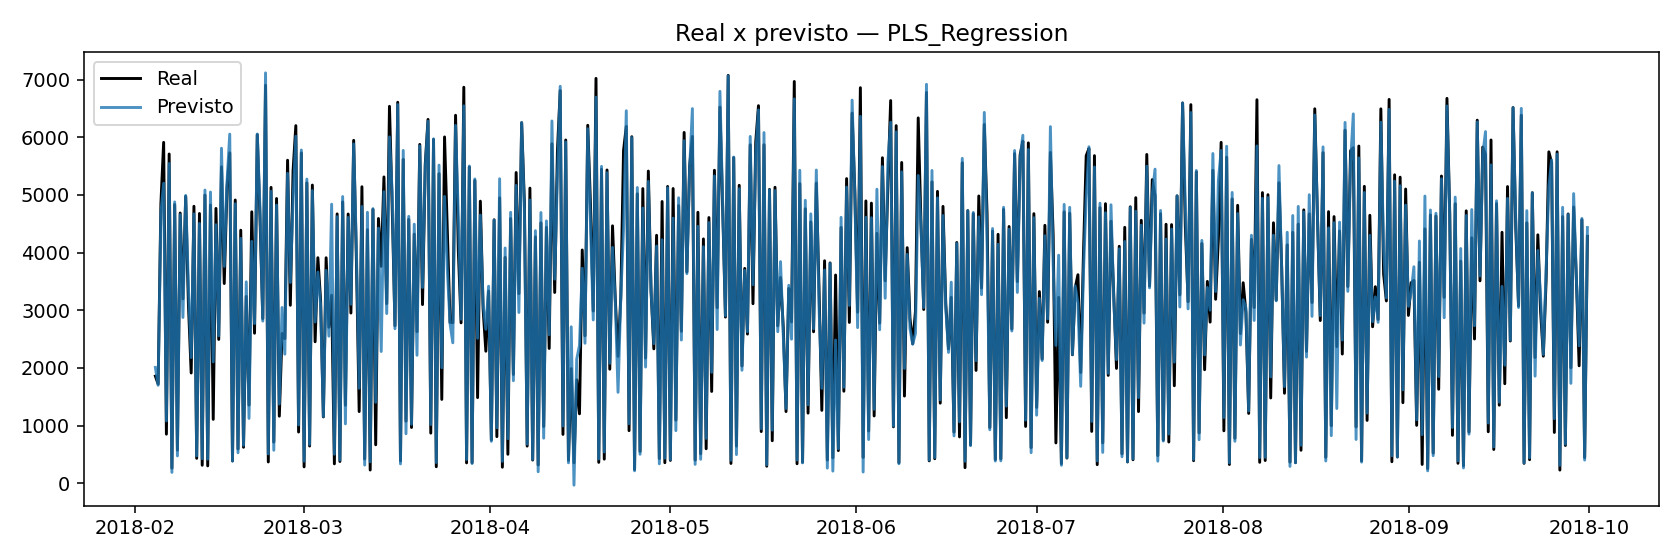

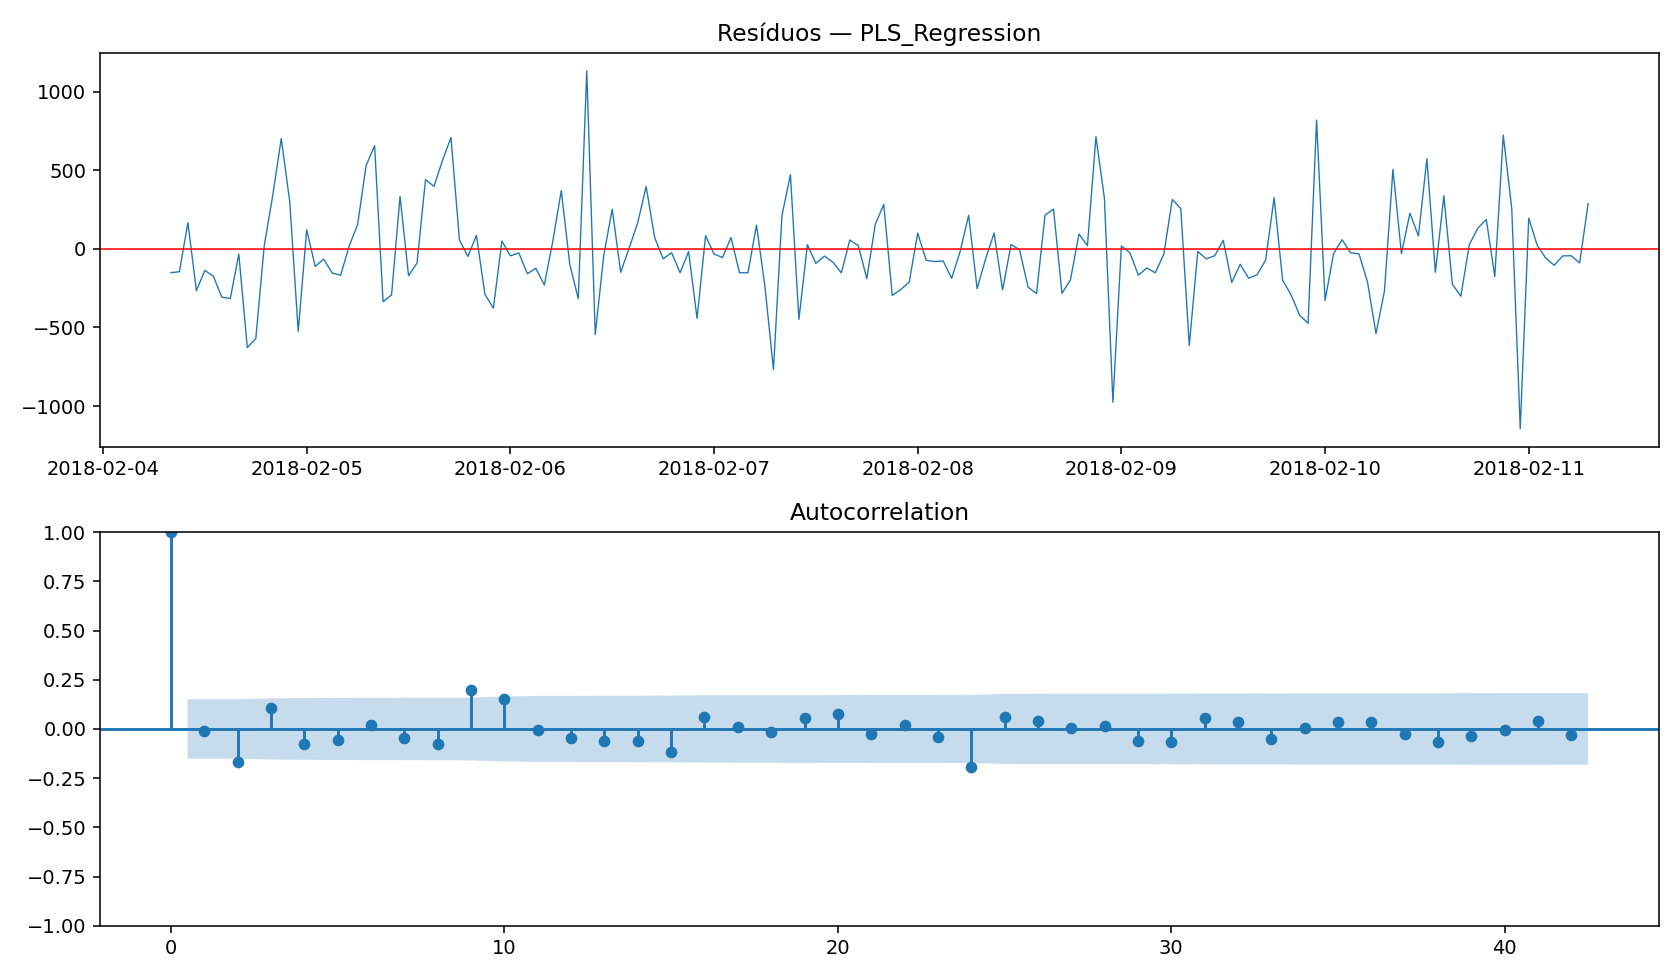

In [2]:
importance = pd.read_csv(require_file(
    config.RESULT_DIR / "feature_importance_PLS_Regression.csv",
    "02_modelos/PLS_Regression/02_walkforward_validacao.ipynb",
))
display(importance)
for name in ("previsao_PLS_Regression.png", "residuos_PLS_Regression.png"):
    display(Image(filename=str(config.FIG_DIR / name)))
